# Weather AI Agent
simple AI agent to tell you if the weather in a specific country is hot or cold

In [13]:
from typing import Annotated, Literal
from typing_extensions import TypedDict
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from langchain_groq import ChatGroq

"""I use a .env file that has my API keys"""
import os
from dotenv import load_dotenv

load_dotenv()
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

In [14]:
import requests, os

resp = requests.get(
    "https://api.groq.com/openai/v1/models",
    headers={"Authorization": f"Bearer {os.environ['GROQ_API_KEY']}"}
)
for m in resp.json()["data"]:
    print(m["id"])

meta-llama/llama-prompt-guard-2-22m
qwen/qwen3.6-27b
whisper-large-v3
canopylabs/orpheus-v1-english
canopylabs/orpheus-arabic-saudi
groq/compound-mini
allam-2-7b
whisper-large-v3-turbo
openai/gpt-oss-20b
groq/compound
openai/gpt-oss-safeguard-20b
meta-llama/llama-prompt-guard-2-86m
openai/gpt-oss-120b


In [15]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph = StateGraph(State)

In [16]:
@tool
def get_weather(location: str):
    """We call this to get the weather"""
    if location.lower():
        return "its hot"
    else:
        return "its cold"

tools = [get_weather]

In [17]:
llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=1.0,
    max_retries=2,
    groq_api_key=GROQ_API_KEY,
)

llm_with_tools = llm.bind_tools(tools)

In [18]:
tool_node = ToolNode(tools)

graph.add_node("tool_node", tool_node)

In [19]:
def prompt_node(state: State) -> State:
    new_message = llm_with_tools.invoke(state['messages'])
    return {"messages": [new_message]}

graph.add_node("prompt_node", prompt_node)

In [20]:
def conditional_edge(state: State) -> Literal['tool_node', '__end__']:
    last_message = state['messages'][-1]
    if last_message.tool_calls:
        return "tool_node"
    else: 
        return "__end__"

graph.add_conditional_edges (
    'prompt_node',
    conditional_edge
)

graph.add_edge("tool_node", "prompt_node")
graph.set_entry_point("prompt_node")

In [21]:
APP = graph.compile()

new_state = APP.invoke({"messages": ["Whats the weather in Egypt?"]})
print(new_state["messages"][-1].content)

It’s hot in Egypt—temperatures typically range from the mid‑70s to 100°F (24–38 °C) depending on the region and time of year.


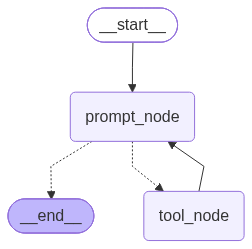

In [22]:
"""Displaying the graph"""
from IPython.display import Image, display
display(Image(APP.get_graph().draw_mermaid_png()))